In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter
import matplotlib.ticker as mticker
from prophet import Prophet

In [2]:
data2 = pd.read_csv('Pepsi.csv')
display(data2)

,Date,Close/Last,Volume,Open,High,Low
0,01/08/2025,$146.54,6791848,$145.40,$146.67,$144.56
1,01/07/2025,$145.40,7473300,$146.46,$147.97,$145.34
2,01/06/2025,$146.27,9470626,$149.60,$149.95,$146.10
3,01/03/2025,$149.65,5221639,$150.96,$150.96,$149.56
4,01/02/2025,$150.21,4970233,$152.88,$153.66,$149.89
...,...,...,...,...,...,...
1253,01/15/2020,$139.20,5002877,$137.04,$139.25,$136.80
1254,01/14/2020,$136.85,4161493,$136.18,$136.94,$135.695
1255,01/13/2020,$136.53,5127511,$134.65,$136.59,$134.63
1256,01/10/2020,$134.53,3100675,$135.17,$135.42,$134.39


In [3]:
clean = data2.iloc[5:].reset_index(drop=True)
clean['Date'] = pd.to_datetime(clean['Date'])
clean['Close/Last'] = clean['Close/Last'].replace('[\$,]', '', regex=True).astype(float)
clean['Quarter'] = clean['Date'].dt.quarter

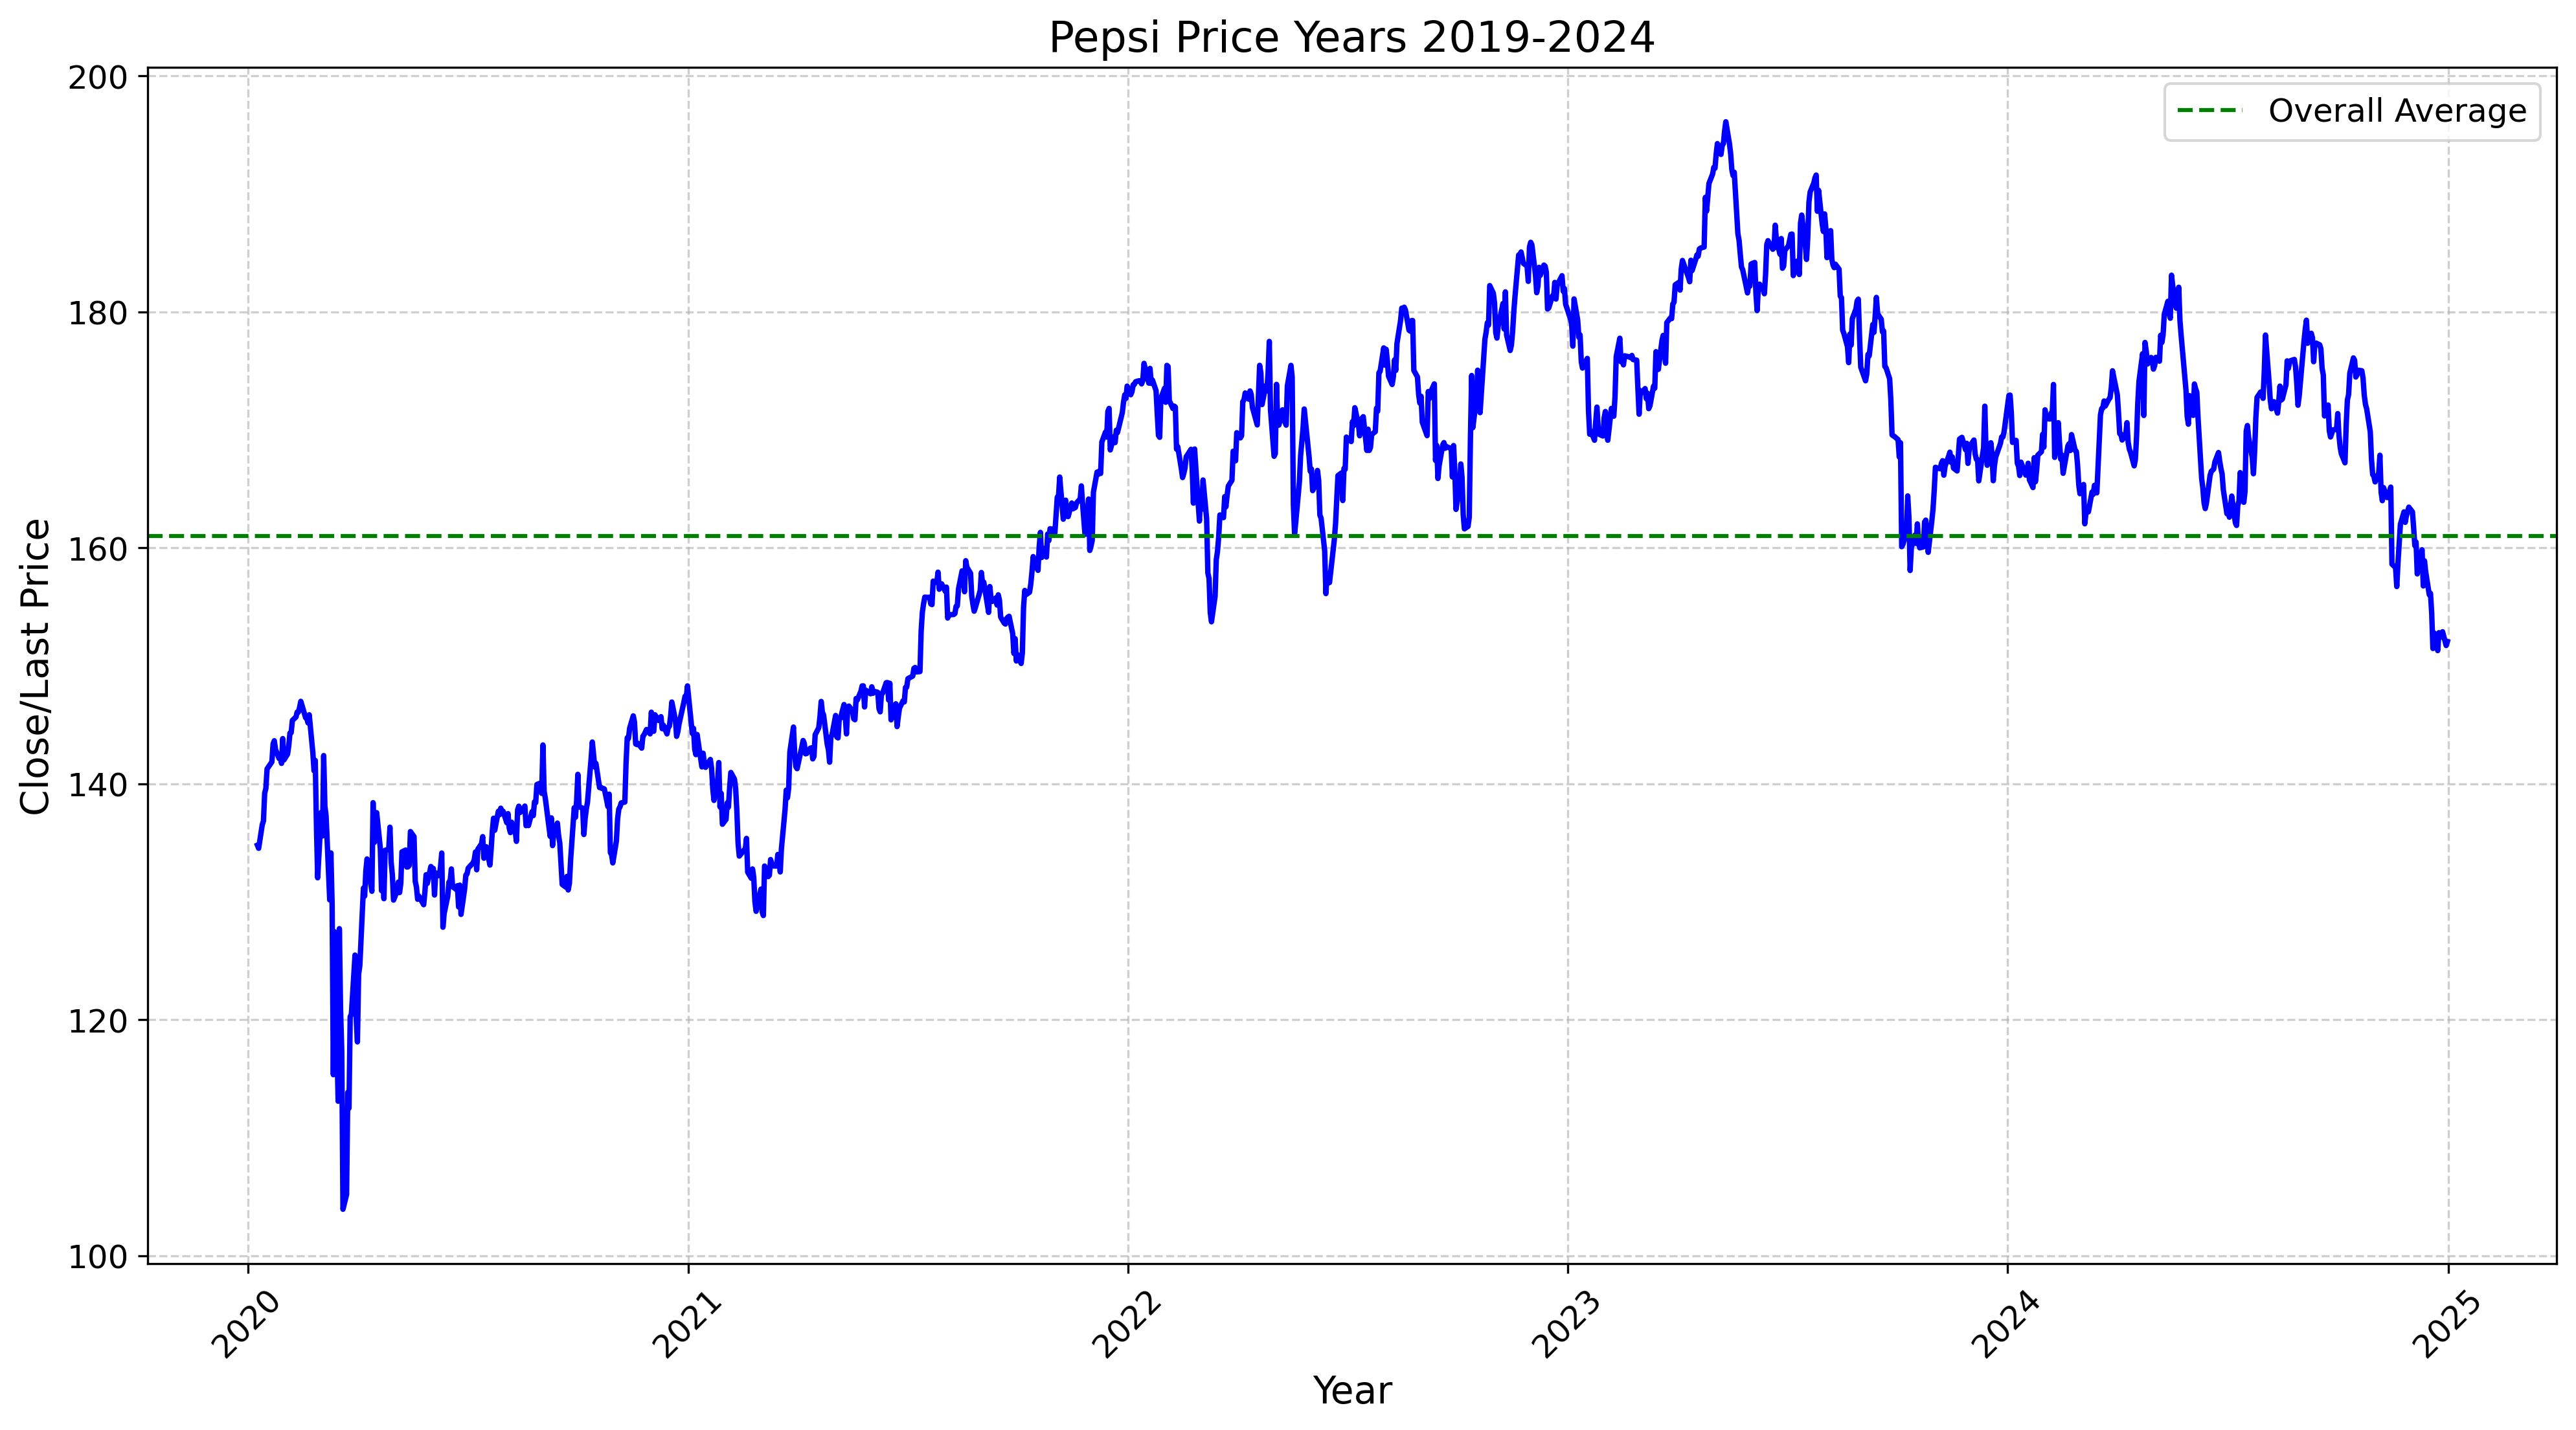

In [4]:
plt.figure(figsize=(16, 8), dpi = 300)

plt.plot(clean['Date'], clean['Close/Last'], linewidth=2, color = 'blue')

overall_avg = clean['Close/Last'].mean()
plt.axhline(overall_avg, color='green', linestyle='--', label='Overall Average')

plt.title('Pepsi Price Years 2019-2024', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Close/Last Price', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)

plt.legend(fontsize=12)
plt.show()

Pepsi has long been known for its global brand strength, steady consumer demand, and diversified product portfolio, which is reflected in this price chart from 2019 to 2024. Even though the share price has experienced swings, there is a clear overall upward trajectory over the past few years. The company benefits from robust distribution networks and a solid international presence, giving it the ability to adapt to changing consumer preferences and navigate economic headwinds. Pepsi’s strong cash flows have historically enabled consistent dividends, which is an appealing factor for investors seeking both income and growth potential. Moreover, as a consumer staples stock, Pepsi tends to show resilience during downturns, making it a relatively stable option for long-term portfolio strategies. When you combine strong brand loyalty, a commitment to product innovation, and the ability to pivot effectively in fluctuating markets, Pepsi stands out as a compelling investment opportunity in the food and beverage sector.

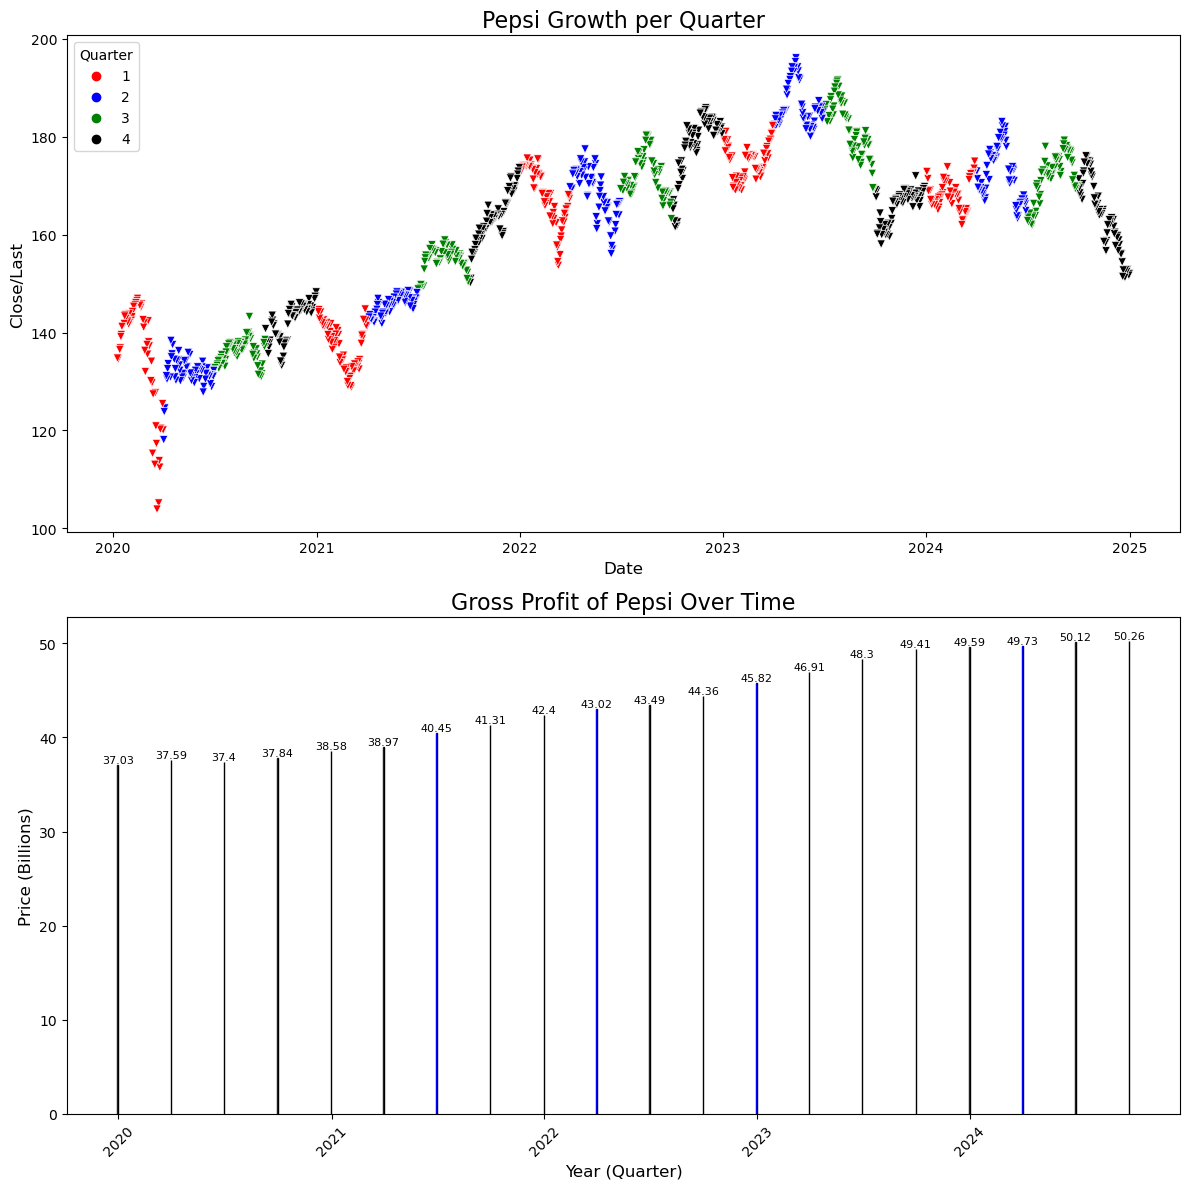

In [5]:
data3 = pd.read_csv('Gross Profit 2.csv')

data3['Date (Quarter)'] = pd.to_datetime(data3['Date (Quarter)'])
data3['Price (Billions)'] = data3['Price (Billions)'].replace('[\$,]', '', regex=True).astype(float) 

fig, axes = plt.subplots(2, 1, figsize=(12, 12))
custom_palette = {1: 'red', 2: 'blue', 3: 'green', 4: 'black'}
sns.scatterplot(
    data=clean,
    x="Date",
    y="Close/Last",
    ax=axes[0],
    hue='Quarter',
    palette=custom_palette,
    marker='v'
)
axes[0].legend(title='Quarter', loc='upper left', fontsize=10)
axes[0].set_title("Pepsi Growth per Quarter", fontsize=16)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Close/Last', fontsize=12)

bars = axes[1].bar(
    data3['Date (Quarter)'], 
    data3['Price (Billions)'], 
    color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] * (len(data2) // 4 + 1), 
    edgecolor='black'
)

axes[1].bar(data3['Date (Quarter)'], data3['Price (Billions)'], color='blue')
axes[1].set_title("Gross Profit of Pepsi Over Time", fontsize=16)
axes[1].set_xlabel('Year (Quarter)', fontsize=12)
axes[1].set_ylabel('Price (Billions)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2.0, 
        height, 
        f'{height:,}', 
        ha='center', 
        va='bottom', 
        fontsize=8)
    
plt.tight_layout()
plt.show()

Pepsi’s quarter-by-quarter price movements may look a bit choppy at first glance due to the COVID, but if you look at the bigger picture, the trend has generally been an upward climb since 2020. That steady performance is supported by rising gross profits, which have grown from around $37 billion in 2020 to over $50 billion more recently. This is a clear sign that Pepsi’s core business is healthy and expanding. When we look at volume data, we can see spikes during certain periods—likely driven by news or earnings reports—indicating that investors remain keenly interested in Pepsi’s future prospects. The combination of a steadily increasing gross profit and sustained market attention suggests that Pepsi has both the strong fundamentals and consistent demand that many investors seek out. If you’re considering a stock that offers a blend of resilience, growth potential, and robust brand strength, Pepsi is worth putting on your radar.

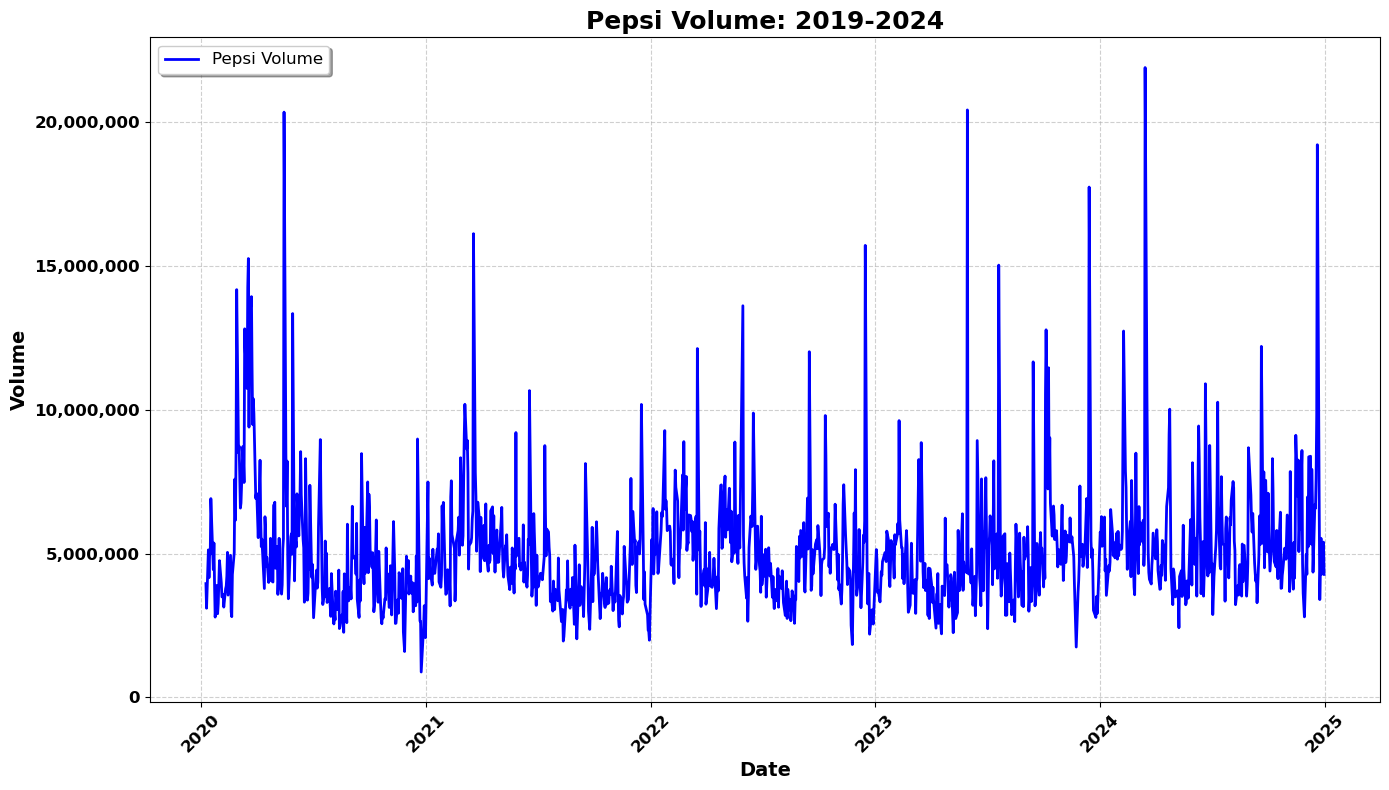

In [6]:
plt.figure(figsize=(14, 8))

plt.plot(clean['Date'], 
    clean['Volume'], 
    linewidth=2, 
    color='blue', 
    label='Pepsi Volume')


plt.title('Pepsi Volume: 2019-2024', fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=14, fontweight='bold')
plt.ylabel('Volume', fontsize=14, fontweight='bold')
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=12, rotation=45, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.legend(fontsize=12, loc='upper left', frameon=True, shadow=True, fancybox=True)
plt.tight_layout()

plt.show()

00:07:11 - cmdstanpy - INFO - Chain [1] start processing
00:07:11 - cmdstanpy - INFO - Chain [1] done processing


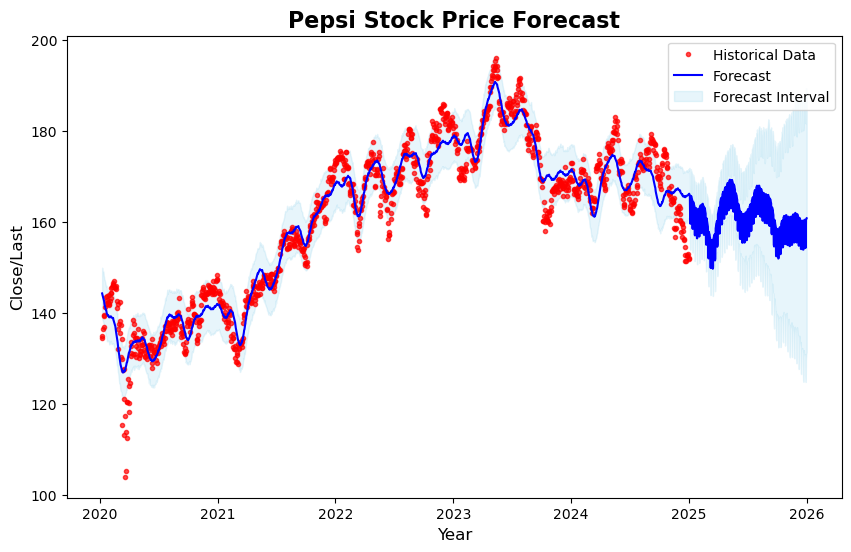

In [7]:
df = clean[['Date', 'Close/Last']]
df = df.rename(columns={'Date': 'ds', 'Close/Last': 'y'})

model = Prophet() 
model.fit(df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

plt.figure(figsize=(10,6))
plt.plot(df['ds'], df['y'], '.', color='red', label='Historical Data', alpha=0.7)
plt.plot(forecast['ds'], forecast['yhat'], 'b-', label='Forecast')

plt.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    color='skyblue',      
    alpha=0.2,        
    label='Forecast Interval'
)

plt.title('Pepsi Stock Price Forecast', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Close/Last', fontsize=12)
plt.legend()
plt.show()

From this forecast visualization, we can see that Pepsi’s stock price exhibited a strong climb from 2020 through its peak in 2023, reflecting solid historical growth. Although there are some dips and corrections along the way—typical in any stock’s journey—the overall trajectory points upward over the long run. By late 2023 into 2024, the forecast suggests a period of moderated performance, reflecting the company’s need to adapt to changing market conditions and broader economic factors.

Moving beyond 2024, the shaded forecast interval widens, which means there is increasing uncertainty in Pepsi’s projected pricing—this is normal for most forward-looking models as they extend further into the future. However, the central forecast line (shown in blue) stays in a relatively stable range, suggesting that Pepsi’s strong fundamentals and brand power may help it maintain a consistent valuation. While the possibility for both higher-than-expected gains and lower-than-anticipated setbacks exists, the overall indication is that Pepsi remains on a path that is reasonably optimistic in the mid-to-long term.